In [1]:
pip install torch torchvision ultralytics pandas tqdm pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00


In [2]:
pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [8]:
import os, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "mps"

IMG_DIR = "./dataset/img_align_celeba/img_align_celeba"
LEFT_IMG_DIR = "./dataset_left"
os.makedirs(LEFT_IMG_DIR, exist_ok=True)
ATTR = "./dataset/list_attr_celeba.csv"
CROP_DIR = "./celeba/faces/predict/crops/face"
os.makedirs(CROP_DIR, exist_ok=True)

SIZE = 64
BATCH = 64
LATENT = 128
LAMBDA = 10

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
yolo_model = YOLO("yolov8n-face.pt")
yolo_model.to(device)
yolo_model.predict(
    LEFT_IMG_DIR,
    save_crop=True,
    exist_ok=True,
    project=CROP_DIR
)

In [ ]:
from CelebA import CelebA

loader = DataLoader(CelebA(CROP_DIR, ATTR, SIZE), batch_size=BATCH, shuffle=True, num_workers=2)

005338.jpg doesn't exist
007726.jpg doesn't exist
009221.jpg doesn't exist
009938.jpg doesn't exist
011598.jpg doesn't exist
011793.jpg doesn't exist
014999.jpg doesn't exist
015549.jpg doesn't exist
016530.jpg doesn't exist
019205.jpg doesn't exist
020344.jpg doesn't exist
021470.jpg doesn't exist
023608.jpg doesn't exist
024184.jpg doesn't exist
024822.jpg doesn't exist
026135.jpg doesn't exist
027185.jpg doesn't exist
028434.jpg doesn't exist
028525.jpg doesn't exist
030782.jpg doesn't exist
031125.jpg doesn't exist
031162.jpg doesn't exist
033692.jpg doesn't exist
034715.jpg doesn't exist
039449.jpg doesn't exist
039459.jpg doesn't exist
041897.jpg doesn't exist
042360.jpg doesn't exist
047421.jpg doesn't exist
047720.jpg doesn't exist
048286.jpg doesn't exist
050763.jpg doesn't exist
050892.jpg doesn't exist
051020.jpg doesn't exist
063507.jpg doesn't exist
067062.jpg doesn't exist
069706.jpg doesn't exist
069956.jpg doesn't exist
069979.jpg doesn't exist
073096.jpg doesn't exist


In [9]:
class Generator(nn.Module):
    def __init__(self, cond = False):
        super().__init__()
        inp = LATENT + (1 if cond else 0)

        self.net = nn.Sequential(
            nn.Linear(inp, 512 * 4 * 4),
            nn.Unflatten(1, (512, 4, 4)),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self,z,c=None):
        if c is not None:
            z = torch.cat([z, c.unsqueeze(1)], 1)
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, cond=False):
        super().__init__()

        ch = 3 + (1 if cond else 0)

        self.net = nn.Sequential(
            nn.Conv2d(ch, 64, 4, 2, 1),
            nn.LeakyReLU(.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.LeakyReLU(.2),

            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 1)
        )

    def forward(self,x,c=None):

        if c is not None:
            c = c.view(-1, 1, 1, 1).expand(-1, 1, SIZE, SIZE)
            x = torch.cat([x, c], 1)

        return self.net(x)

In [10]:
def gradient_penalty(D, real, fake, c=None):

    a = torch.rand(real.size(0), 1, 1, 1, device=device)

    inter = (a * real + (1 - a) * fake).requires_grad_(True)

    d = D(inter, c)

    grad = torch.autograd.grad(
        d, inter,
        torch.ones_like(d),
        create_graph=True
    )[0]

    grad = grad.view(grad.size(0), -1)

    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

In [11]:
def plot_loss(generator_losses, discriminator_losses, epoch, max_epochs):
    plt.figure(figsize=(8, 4))
    plt.plot(generator_losses, label="Generator Loss")
    plt.plot(discriminator_losses, label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"GAN Losses During Training. Epoch {epoch}/{max_epochs}")
    plt.show()

In [ ]:
def train(cond=False, epochs=5):

    G = Generator(cond).to(device)
    D = Discriminator(cond).to(device)

    optG = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
    optD = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.0, 0.9))

    gen_losses = []
    disc_losses = []

    for e in range(epochs):

        cur_gen_losses = []
        cur_disc_losses = []

        for real, c in tqdm(loader):

            real = real.to(device)
            c = c.to(device)

            for _ in range(3):

                z = torch.randn(real.size(0), LATENT, device=device)

                fake = G(z, c if cond else None).detach()

                lossD = (
                    D(fake, c if cond else None).mean()
                    - D(real, c if cond else None).mean()
                    + LAMBDA * gradient_penalty(
                        D, real, fake, c if cond else None
                    )
                )

                cur_disc_losses.append(lossD.item())

                optD.zero_grad()
                lossD.backward()
                optD.step()

            z = torch.randn(real.size(0), LATENT, device=device)

            fake = G(z, c if cond else None)

            lossG = -D(fake, c if cond else None).mean()

            cur_gen_losses.append(lossG.item())

            optG.zero_grad()
            lossG.backward()
            optG.step()

        with torch.no_grad():
            fig, axes = plt.subplots(1, 5, figsize=(15, 3))

            for ax in axes:
              z = torch.randn(1, LATENT).to(device)
              c = torch.tensor([1]).float().to(device) if cond else None
              img = (G(z, c)[0] + 1) / 2
              img = transforms.ToPILImage()(img)
              ax.imshow(img)
              ax.axis("off")

            plt.tight_layout()
            plt.show()

        print("epoch", e, "D", lossD.item(), "G", lossG.item())

        gen_losses.append(sum(cur_gen_losses) / len(cur_gen_losses))
        disc_losses.append(sum(cur_disc_losses) / len(cur_disc_losses))
        if e > 0:
          plot_loss(gen_losses, disc_losses, e, epochs)

    torch.save(G.state_dict(), f"generator{cond}.pt")

    return G

In [15]:
def generate(G, n=100, save_dir="content/gen", cond=None):

    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():

        for i in range(n):

            z = torch.randn(1, LATENT).to(device)

            c = torch.tensor([cond]).float().to(device) if cond is not None else None

            img = (G(z, c)[0] + 1) / 2

            transforms.ToPILImage()(img).save(f"{save_dir}/{i}.png")

  0%|          | 0/3164 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 3164/3164 [10:53<00:00,  4.84it/s]


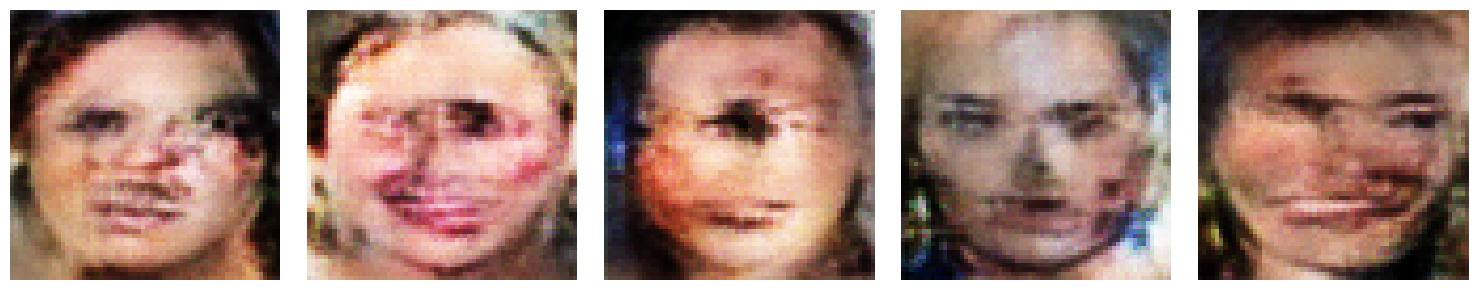

epoch 0 D -4.578161239624023 G -8.286380767822266


100%|██████████| 3164/3164 [11:05<00:00,  4.76it/s]


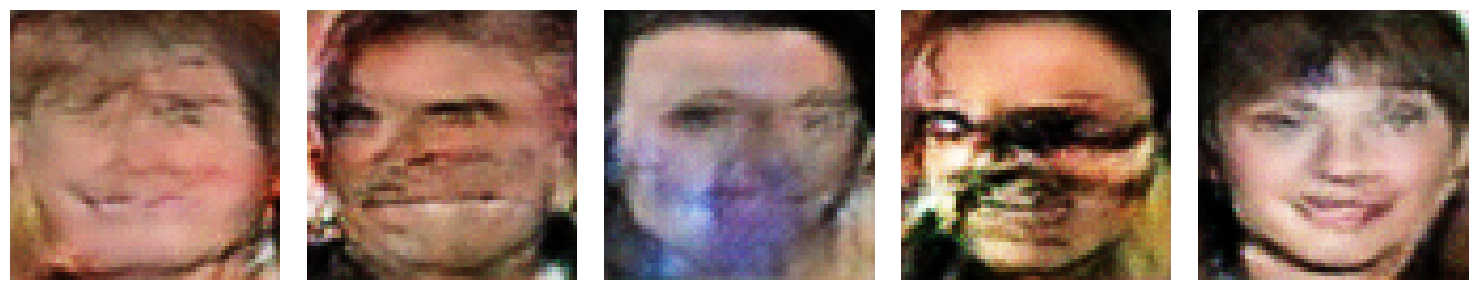

epoch 1 D -3.9798731803894043 G -7.700226783752441


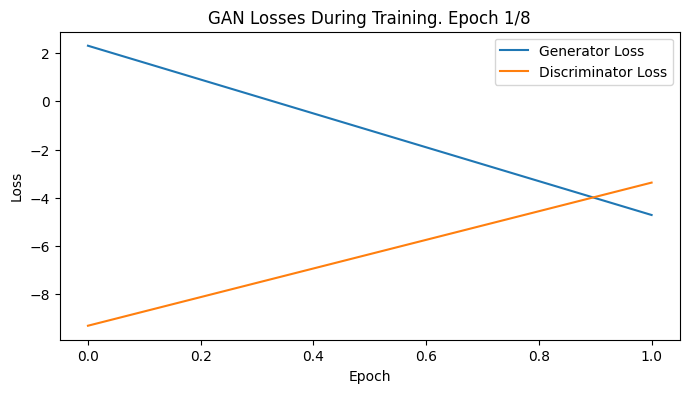

100%|██████████| 3164/3164 [11:04<00:00,  4.77it/s]


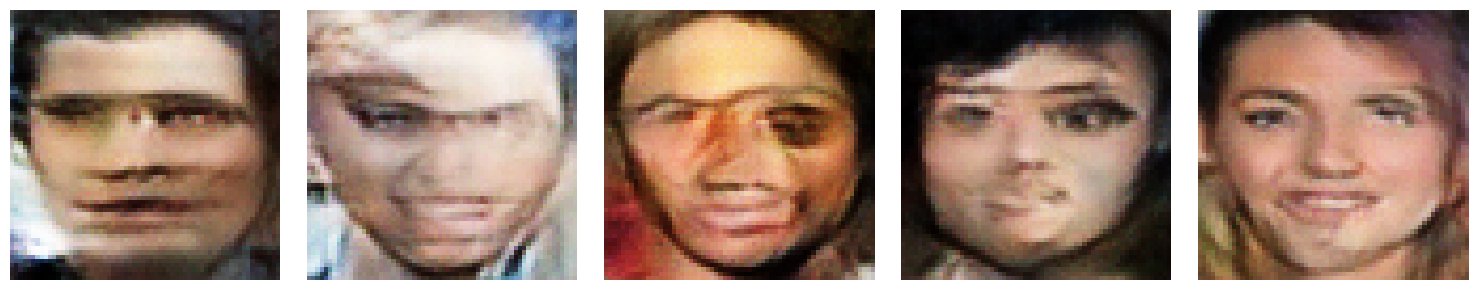

epoch 2 D -2.0026867389678955 G -5.627709865570068


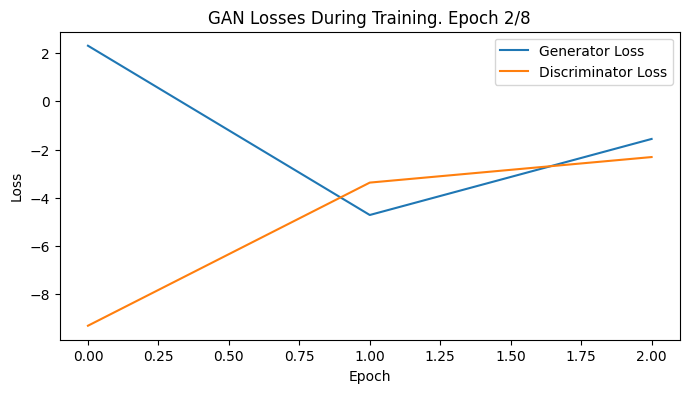

100%|██████████| 3164/3164 [11:05<00:00,  4.76it/s]


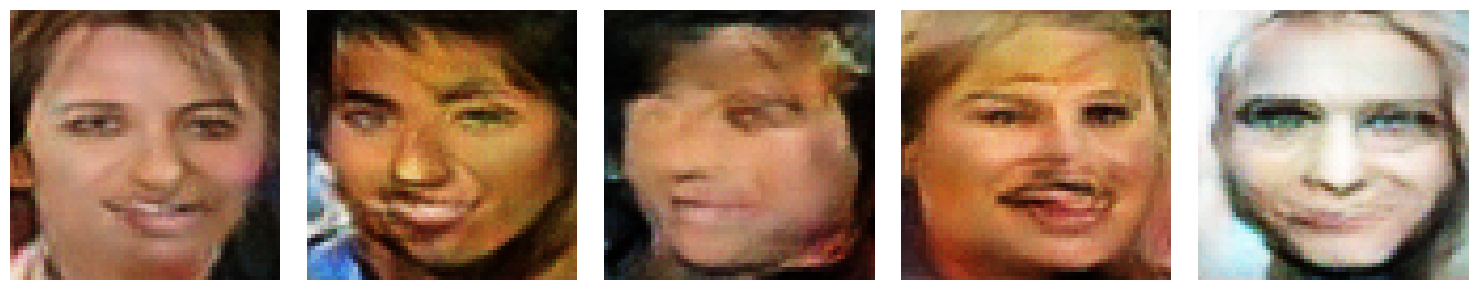

epoch 3 D -1.126414179801941 G 6.5039262771606445


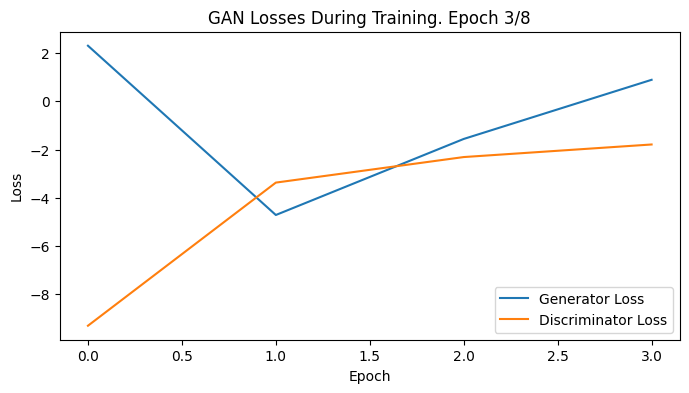

100%|██████████| 3164/3164 [11:06<00:00,  4.75it/s]


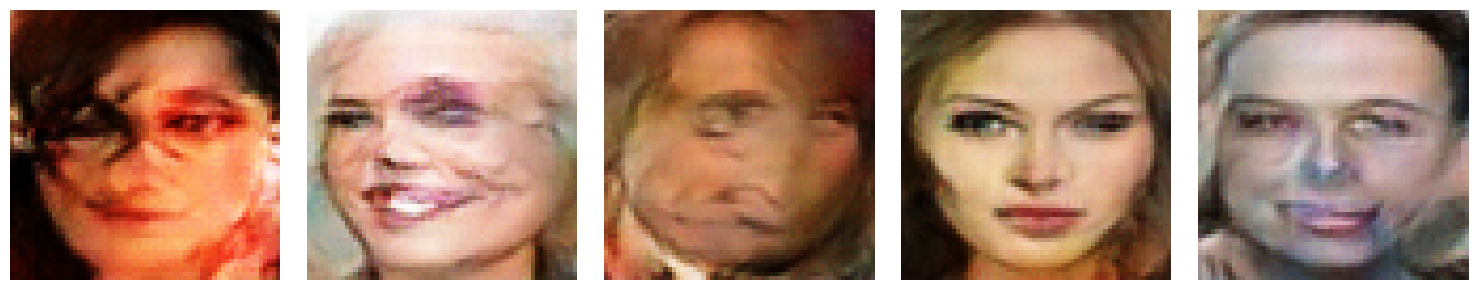

epoch 4 D -2.8481576442718506 G -3.1579089164733887


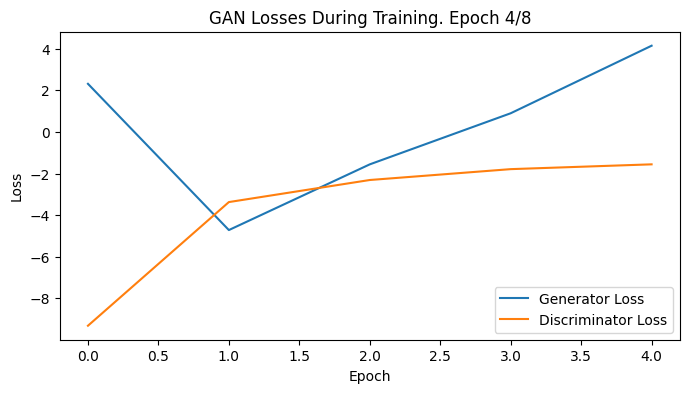

100%|██████████| 3164/3164 [10:53<00:00,  4.84it/s]


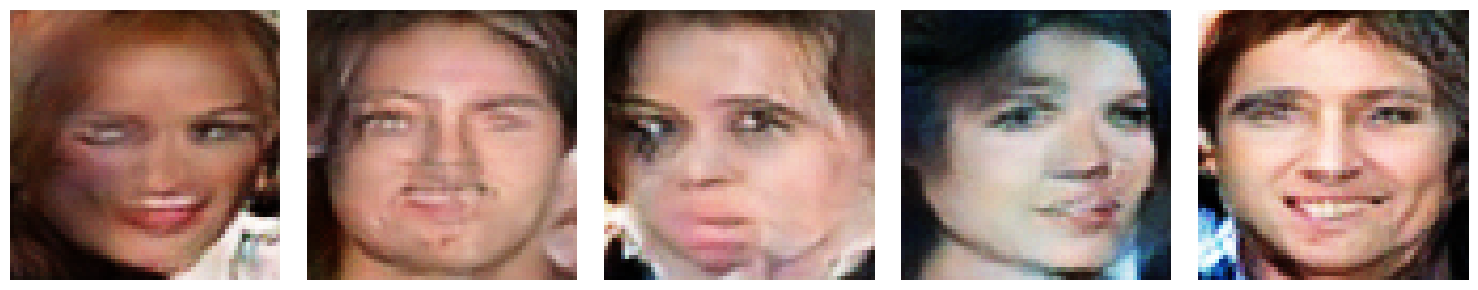

epoch 5 D -2.491469383239746 G 9.149650573730469


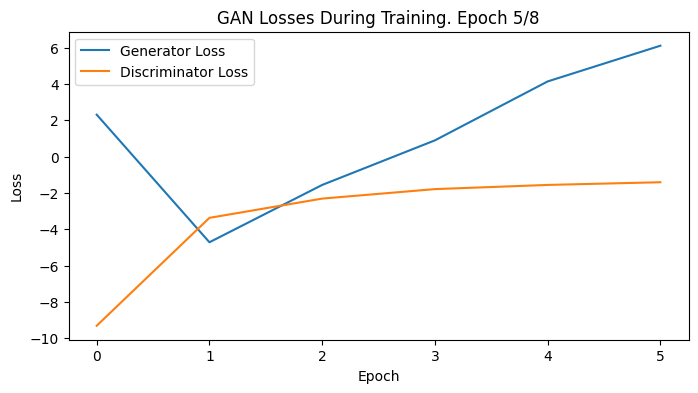

100%|██████████| 3164/3164 [10:52<00:00,  4.85it/s]


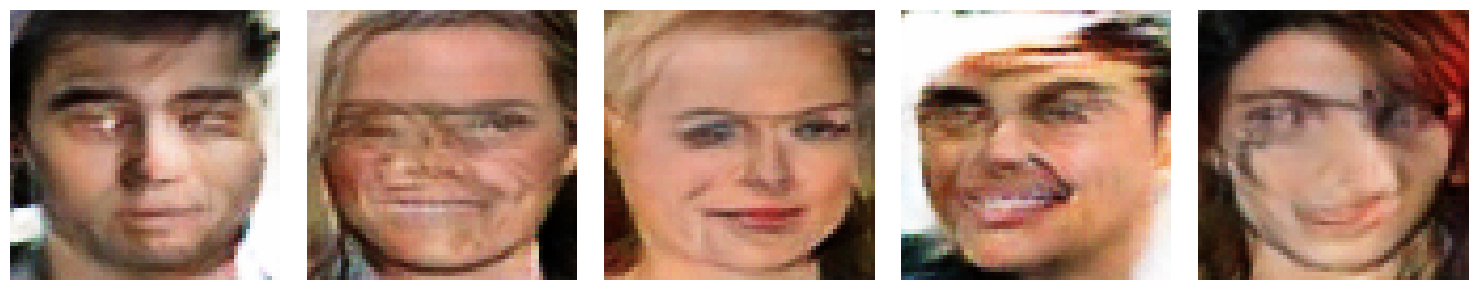

epoch 6 D -1.8845798969268799 G 6.546560287475586


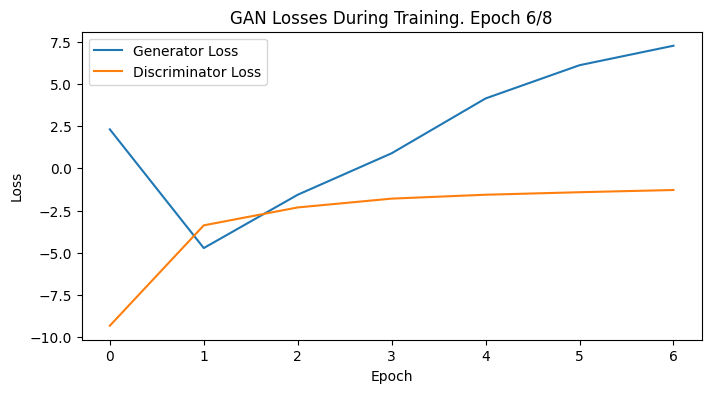

100%|██████████| 3164/3164 [10:53<00:00,  4.84it/s]


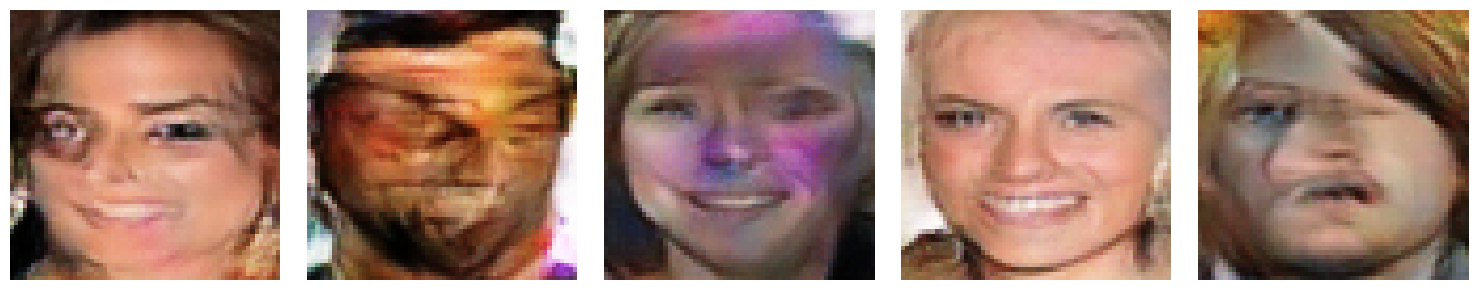

epoch 7 D -2.1419901847839355 G 9.463557243347168


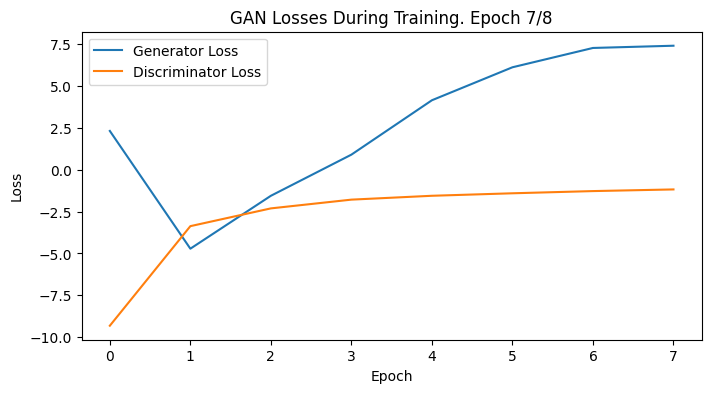

100%|██████████| 3164/3164 [11:01<00:00,  4.79it/s]


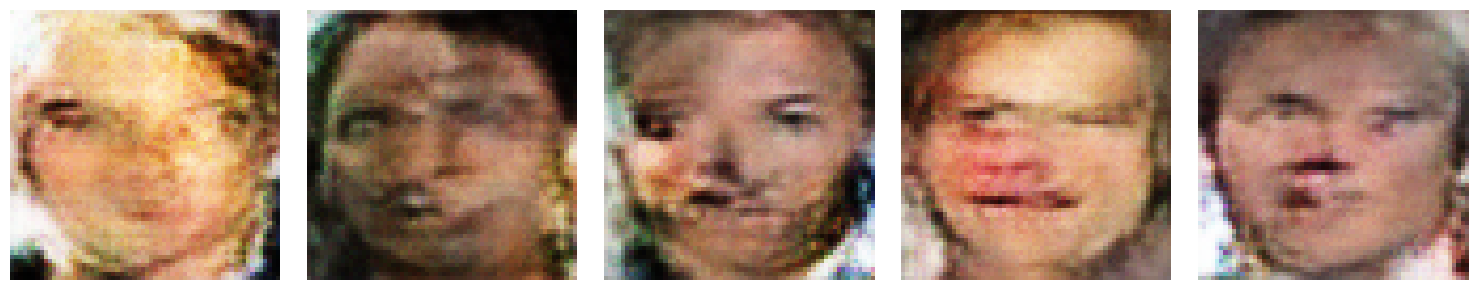

epoch 0 D -4.5392680168151855 G -13.875259399414062


100%|██████████| 3164/3164 [11:01<00:00,  4.79it/s]


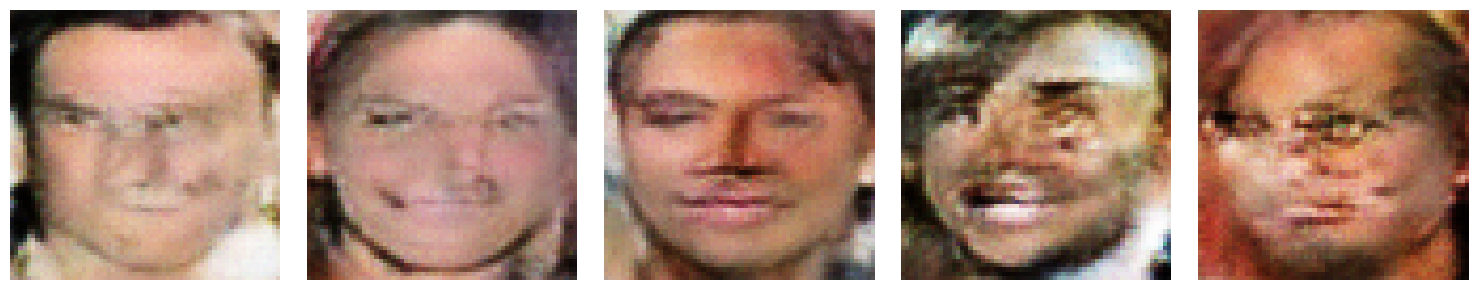

epoch 1 D -4.557747840881348 G -21.81159782409668


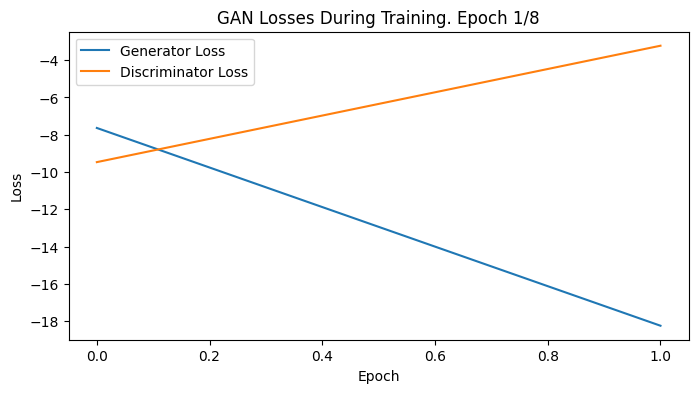

100%|██████████| 3164/3164 [11:01<00:00,  4.78it/s]


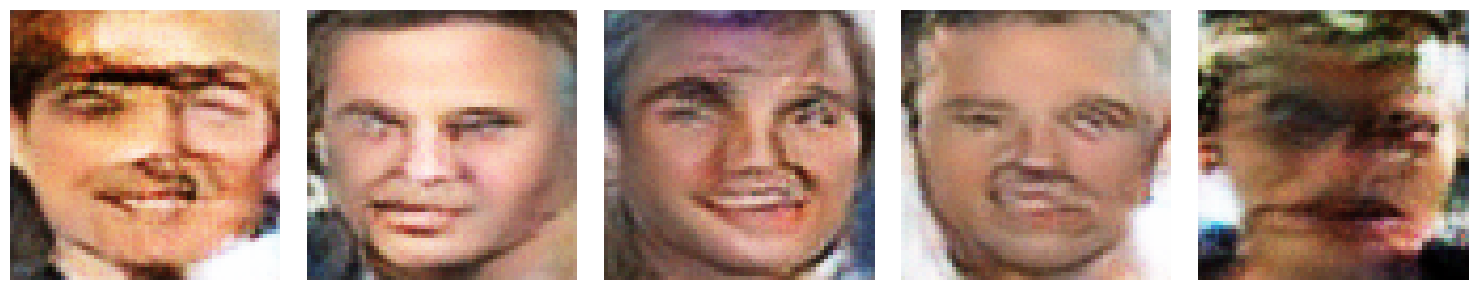

epoch 2 D -3.0672178268432617 G 0.2557255029678345


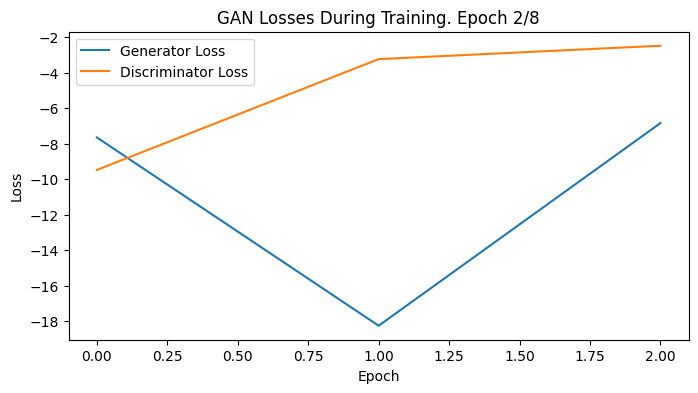

100%|██████████| 3164/3164 [11:01<00:00,  4.78it/s]


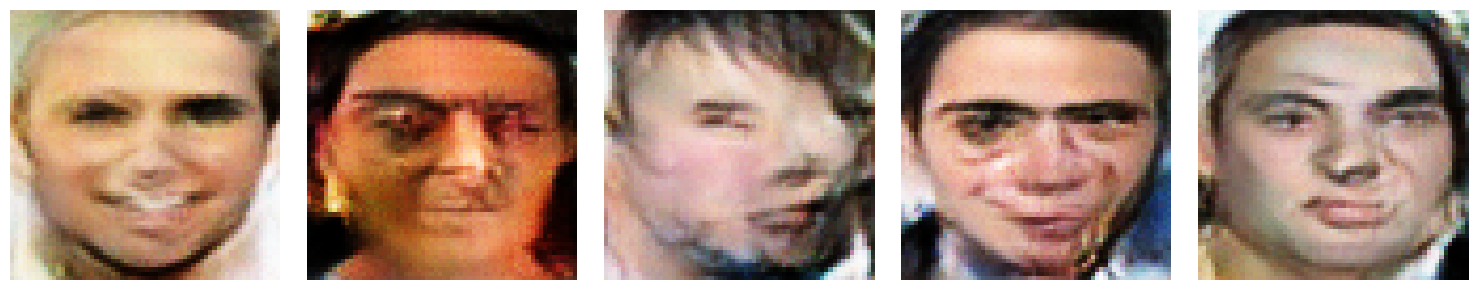

epoch 3 D -1.9129770994186401 G 0.3462217152118683


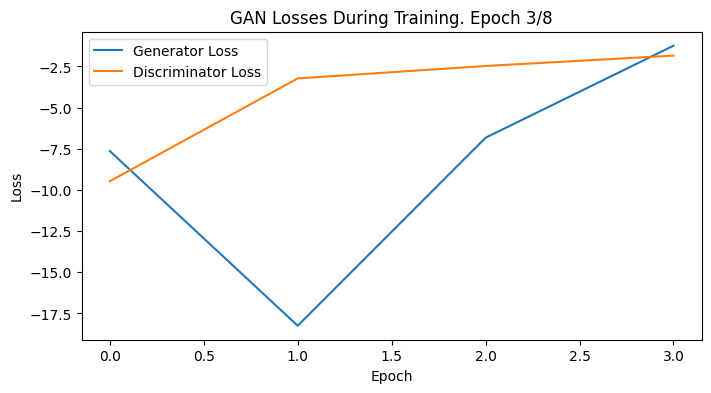

100%|██████████| 3164/3164 [11:01<00:00,  4.78it/s]


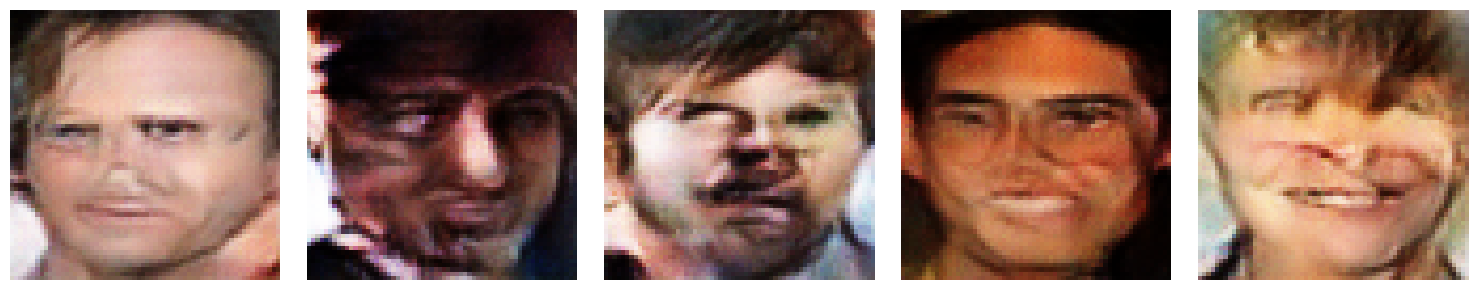

epoch 4 D -1.5367882251739502 G -0.16160689294338226


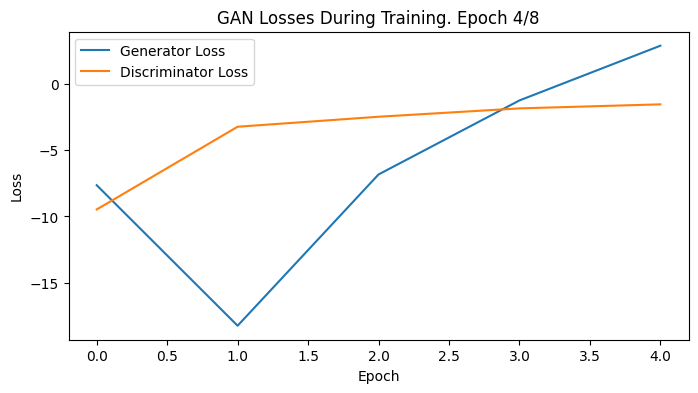

100%|██████████| 3164/3164 [11:01<00:00,  4.78it/s]


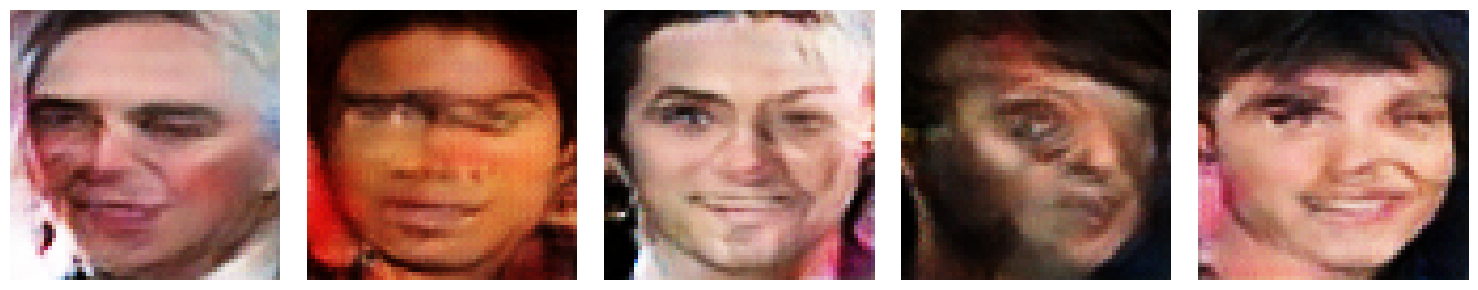

epoch 5 D -1.4546881914138794 G 5.951237678527832


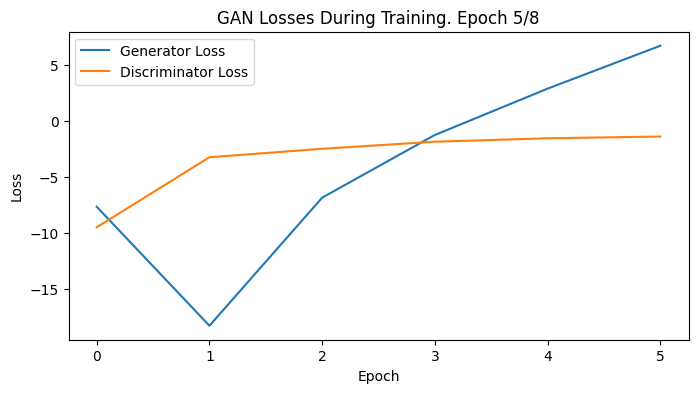

100%|██████████| 3164/3164 [11:01<00:00,  4.78it/s]


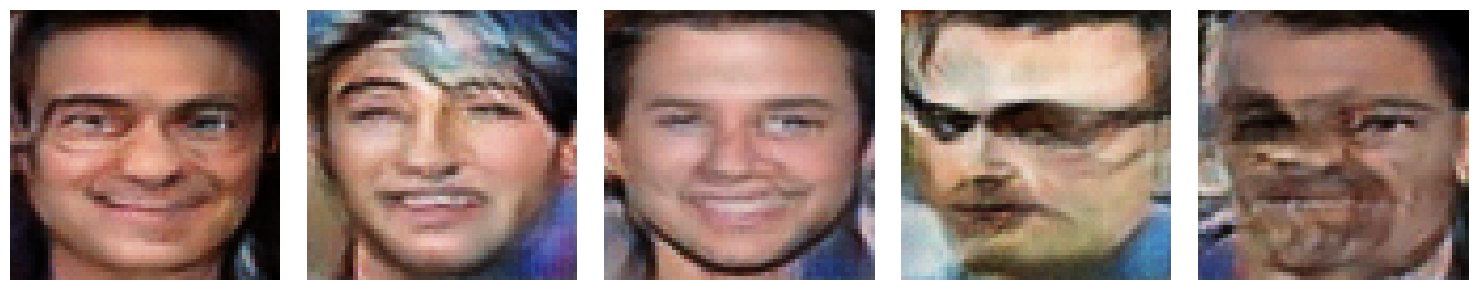

epoch 6 D -1.9118480682373047 G 6.4935126304626465


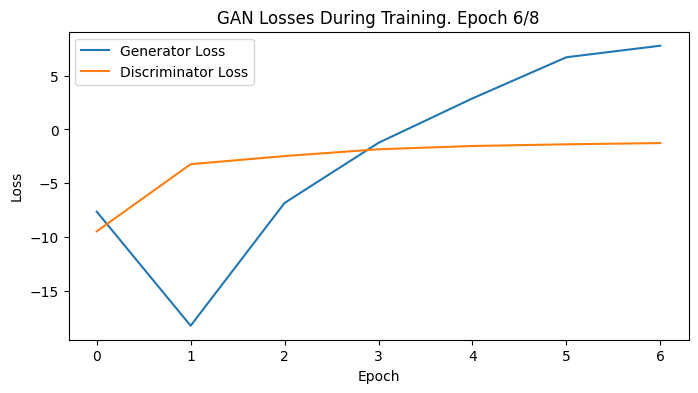

100%|██████████| 3164/3164 [11:01<00:00,  4.78it/s]


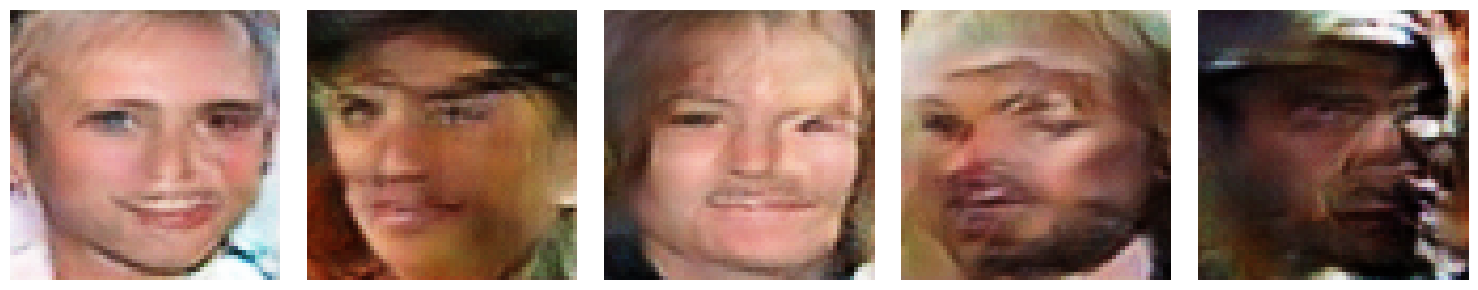

epoch 7 D -1.8730708360671997 G 6.94370698928833


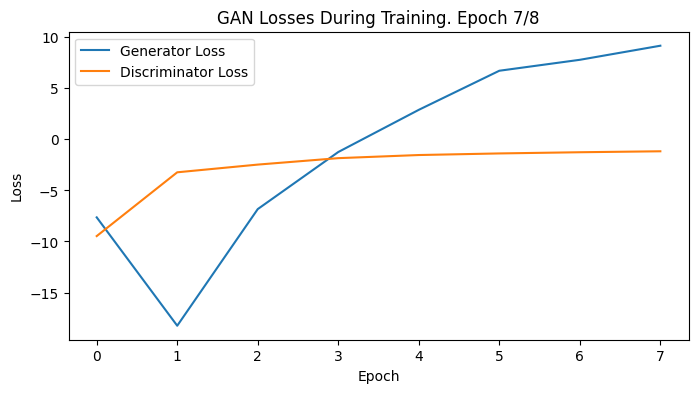

In [ ]:
G_uncond = train(cond=False, epochs=8)
generate(G_uncond)

G_cond = train(cond=True, epochs=8)
generate(G_cond, save_dir="content/malegen", cond=1)
generate(G_cond, save_dir="content/femalegen", cond=-1)

In [13]:
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.8 MB/s eta 0:00:00


In [16]:
G_uncond = Generator(cond=False).to(device)
G_cond = Generator(cond=True).to(device)
G_uncond.load_state_dict(torch.load("generatorFalse.pt", map_location=device))
G_cond.load_state_dict(torch.load("generatorTrue.pt", map_location=device))

generate(G_uncond, n=5000)
generate(G_cond, save_dir="content/malegen", cond=1)
generate(G_cond, save_dir="content/femalegen", cond=-1)

In [12]:
from PIL import Image
import os
from tqdm import tqdm

CROP_RESIZE_DIR = "celeba/resized"
os.makedirs(CROP_RESIZE_DIR, exist_ok=True)

def save_resize(from_img_dir, to_img_dir):
    for file in tqdm(os.listdir(from_img_dir)):
        if os.path.isfile(os.path.join(from_img_dir, file)):
            img = Image.open(os.path.join(from_img_dir, file))
            img.resize((SIZE, SIZE)).save(os.path.join(to_img_dir, file))

save_resize(CROP_DIR, CROP_RESIZE_DIR)

100%|██████████| 207042/207042 [03:32<00:00, 974.91it/s]


In [18]:
import torch_fidelity

metrics = torch_fidelity.calculate_metrics(
    input1="./content/gen",
    input2=CROP_RESIZE_DIR,
    cuda=True,
    isc=True,
    fid=True,
    kid=False,
    verbose=True
)

print(metrics)

Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 209MB/s]
Extracting features from input1
Looking for samples non-recursivelty in "./content/gen" with extensions png,jpg,jpeg
Found 5000 samples
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Processing samples:   0%|          | 0/

{'inception_score_mean': 1.8661612412573096, 'inception_score_std': 0.03787427293535941, 'frechet_inception_distance': 50.84178711767683}


Frechet Inception Distance: 50.84179
